# Анализ экспертных оценок по кейсам

Ноутбук читает CSV-файл `expert_case_scores_final.csv`, выводит исходную таблицу, считает распределение оценок по двум показателям и строит графики через `matplotlib`.

Показатели:

- качество договора;
- качество отчета/рекомендаций.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_colwidth", 100)

df = pd.read_csv("expert_case_scores.csv")
display(df)


,№ кейса,тип договора,Э1 — договор,Э2 — договор,Э3 — договор,Э1 — отчет/рекомендации,Э2 — отчет/рекомендации,Э3 — отчет/рекомендации
0,1,договор купли-продажи,4,5,4,5,5,4
1,2,договор продажи недвижимости,5,4,5,5,5,5
2,3,договор дарения,4,4,5,4,5,5
3,4,договор мены,4,4,4,5,4,5
4,5,договор займа,4,5,4,4,5,5
5,6,договор аренды,5,4,5,5,4,5
6,7,договор проката,4,4,4,4,5,5
7,8,договор найма жилого помещения,5,5,4,5,5,5
8,9,договор подряда,4,5,4,4,5,5
9,10,договор возмездного оказания услуг,5,4,5,5,4,5


## 1. Проверка данных

In [5]:
print("Размер таблицы:", df.shape)

print("\nТипы данных:")
display(df.dtypes.to_frame("тип данных"))

print("\nПропуски по колонкам:")
display(df.isna().sum().to_frame("количество пропусков"))

score_columns = [col for col in df.columns if col.startswith("Э")]
print("\nМинимальная оценка:", df[score_columns].min().min())
print("Максимальная оценка:", df[score_columns].max().max())


Размер таблицы: (11, 8)

Типы данных:


,тип данных
№ кейса,int64
тип договора,object
Э1 — договор,int64
Э2 — договор,int64
Э3 — договор,int64
Э1 — отчет/рекомендации,int64
Э2 — отчет/рекомендации,int64
Э3 — отчет/рекомендации,int64



Пропуски по колонкам:


,количество пропусков
№ кейса,0
тип договора,0
Э1 — договор,0
Э2 — договор,0
Э3 — договор,0
Э1 — отчет/рекомендации,0
Э2 — отчет/рекомендации,0
Э3 — отчет/рекомендации,0



Минимальная оценка: 4
Максимальная оценка: 5


## 2. Разделение колонок по показателям

In [6]:
contract_cols = [col for col in df.columns if col.startswith("Э") and "договор" in col]
recommendation_cols = [col for col in df.columns if col.startswith("Э") and "отчет/рекомендации" in col]

print("Колонки показателя «качество договора»:")
print(contract_cols)

print("\nКолонки показателя «качество рекомендаций»:")
print(recommendation_cols)


Колонки показателя «качество договора»:
['Э1 — договор', 'Э2 — договор', 'Э3 — договор']

Колонки показателя «качество рекомендаций»:
['Э1 — отчет/рекомендации', 'Э2 — отчет/рекомендации', 'Э3 — отчет/рекомендации']


## 3. Сколько раз встречается каждая оценка

Сводная таблица показывает, сколько оценок 4 и 5 было поставлено по каждому показателю.


In [7]:
contract_counts = df[contract_cols].stack().value_counts().sort_index()
recommendation_counts = df[recommendation_cols].stack().value_counts().sort_index()

summary_counts = pd.DataFrame({
    "качество договора": contract_counts,
    "качество рекомендаций": recommendation_counts,
}).fillna(0).astype(int)

summary_counts.index.name = "оценка"

display(summary_counts)


,качество договора,качество рекомендаций
оценка,,
4,19,9
5,14,24


## 4. Процентное распределение оценок

In [8]:
summary_percent = summary_counts.div(summary_counts.sum(axis=0), axis=1) * 100
summary_percent = summary_percent.round(1)

display(summary_percent)


,качество договора,качество рекомендаций
оценка,,
4,57.6,27.3
5,42.4,72.7


## 5. Длинный формат таблицы

Длинный формат удобен для группировки данных по экспертам, кейсам и показателям.


In [9]:
contract_long = df.melt(
    id_vars=["№ кейса", "тип договора"],
    value_vars=contract_cols,
    var_name="эксперт",
    value_name="оценка",
)
contract_long["эксперт"] = contract_long["эксперт"].str.extract(r"(Э\d)")
contract_long["показатель"] = "качество договора"

recommendation_long = df.melt(
    id_vars=["№ кейса", "тип договора"],
    value_vars=recommendation_cols,
    var_name="эксперт",
    value_name="оценка",
)
recommendation_long["эксперт"] = recommendation_long["эксперт"].str.extract(r"(Э\d)")
recommendation_long["показатель"] = "качество рекомендаций"

long_df = pd.concat([contract_long, recommendation_long], ignore_index=True)

display(long_df.head(12))


,№ кейса,тип договора,эксперт,оценка,показатель
0,1,договор купли-продажи,Э1,4,качество договора
1,2,договор продажи недвижимости,Э1,5,качество договора
2,3,договор дарения,Э1,4,качество договора
3,4,договор мены,Э1,4,качество договора
4,5,договор займа,Э1,4,качество договора
5,6,договор аренды,Э1,5,качество договора
6,7,договор проката,Э1,4,качество договора
7,8,договор найма жилого помещения,Э1,5,качество договора
8,9,договор подряда,Э1,4,качество договора
9,10,договор возмездного оказания услуг,Э1,5,качество договора


## 6. Средние оценки по показателям

In [10]:
mean_by_indicator = (
    long_df
    .groupby("показатель")["оценка"]
    .mean()
    .round(2)
    .to_frame("средняя оценка")
)

display(mean_by_indicator)


,средняя оценка
показатель,
качество договора,4.42
качество рекомендаций,4.73


## 7. Средние оценки по кейсам

Для каждого кейса считается средняя оценка договора, средняя оценка рекомендаций и разница между ними.


In [11]:
case_analysis = df[["№ кейса", "тип договора"]].copy()

case_analysis["средняя оценка договора"] = df[contract_cols].mean(axis=1).round(2)
case_analysis["средняя оценка рекомендаций"] = df[recommendation_cols].mean(axis=1).round(2)
case_analysis["разница рекомендации − договор"] = (
    case_analysis["средняя оценка рекомендаций"] - case_analysis["средняя оценка договора"]
).round(2)

display(case_analysis)


,№ кейса,тип договора,средняя оценка договора,средняя оценка рекомендаций,разница рекомендации − договор
0,1,договор купли-продажи,4.33,4.67,0.34
1,2,договор продажи недвижимости,4.67,5.00,0.33
2,3,договор дарения,4.33,4.67,0.34
3,4,договор мены,4.00,4.67,0.67
4,5,договор займа,4.33,4.67,0.34
5,6,договор аренды,4.67,4.67,0.00
6,7,договор проката,4.00,4.67,0.67
7,8,договор найма жилого помещения,4.67,5.00,0.33
8,9,договор подряда,4.33,4.67,0.34
9,10,договор возмездного оказания услуг,4.67,4.67,0.00


## 8. Средние оценки по экспертам

In [12]:
expert_analysis = (
    long_df
    .groupby(["эксперт", "показатель"])["оценка"]
    .mean()
    .unstack()
    .round(2)
)

expert_analysis["разница рекомендации − договор"] = (
    expert_analysis["качество рекомендаций"] - expert_analysis["качество договора"]
).round(2)

display(expert_analysis)


показатель,качество договора,качество рекомендаций,разница рекомендации − договор
эксперт,,,
Э1,4.36,4.55,0.19
Э2,4.45,4.73,0.28
Э3,4.45,4.91,0.46


## 9. График: распределение оценок по показателям

Этот график построен через `matplotlib`.


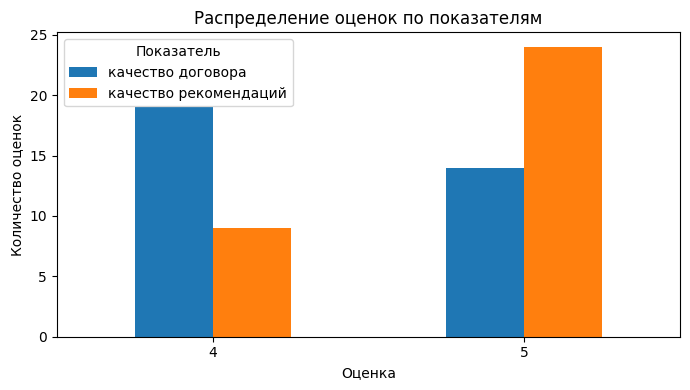

In [13]:
ax = summary_counts.plot(kind="bar", figsize=(7, 4))

ax.set_title("Распределение оценок по показателям")
ax.set_xlabel("Оценка")
ax.set_ylabel("Количество оценок")
ax.legend(title="Показатель")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 10. График: процентное распределение оценок

Этот график также построен через `matplotlib`.


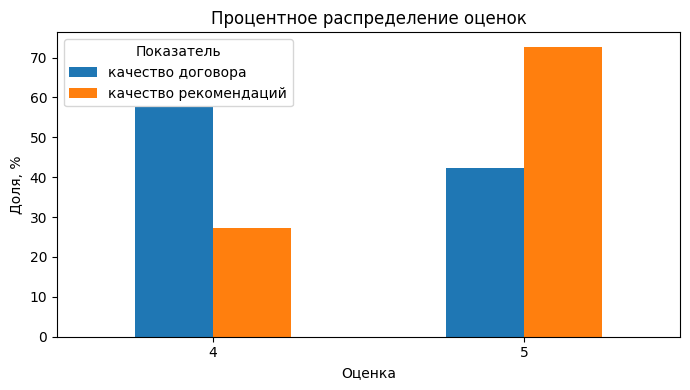

In [14]:
ax = summary_percent.plot(kind="bar", figsize=(7, 4))

ax.set_title("Процентное распределение оценок")
ax.set_xlabel("Оценка")
ax.set_ylabel("Доля, %")
ax.legend(title="Показатель")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 11. График: средние оценки по кейсам

Сравниваются средние оценки договора и рекомендаций по каждому кейсу.


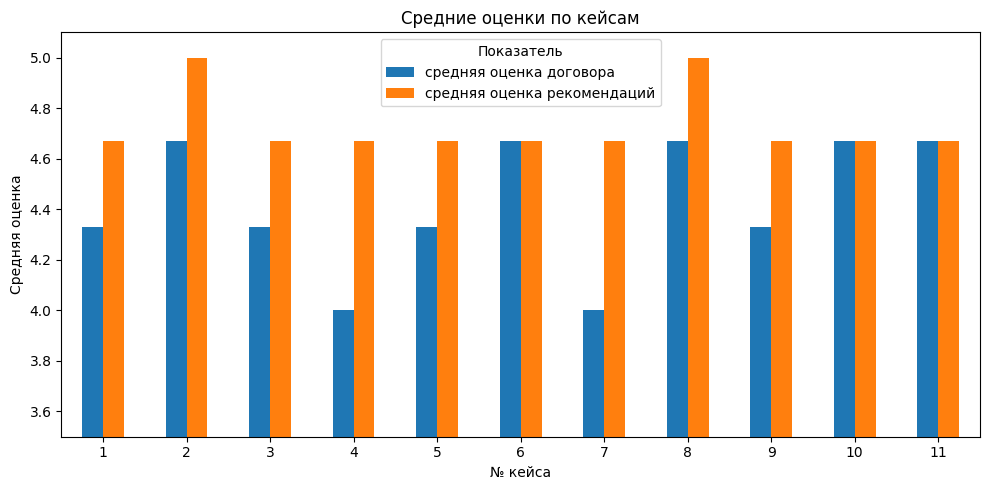

In [15]:
case_plot = case_analysis.set_index("№ кейса")[
    ["средняя оценка договора", "средняя оценка рекомендаций"]
]

ax = case_plot.plot(kind="bar", figsize=(10, 5))

ax.set_title("Средние оценки по кейсам")
ax.set_xlabel("№ кейса")
ax.set_ylabel("Средняя оценка")
ax.set_ylim(3.5, 5.1)
ax.legend(title="Показатель")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 12. График: разница между рекомендациями и договором

Положительное значение означает, что рекомендации в среднем оценены выше, чем договор.


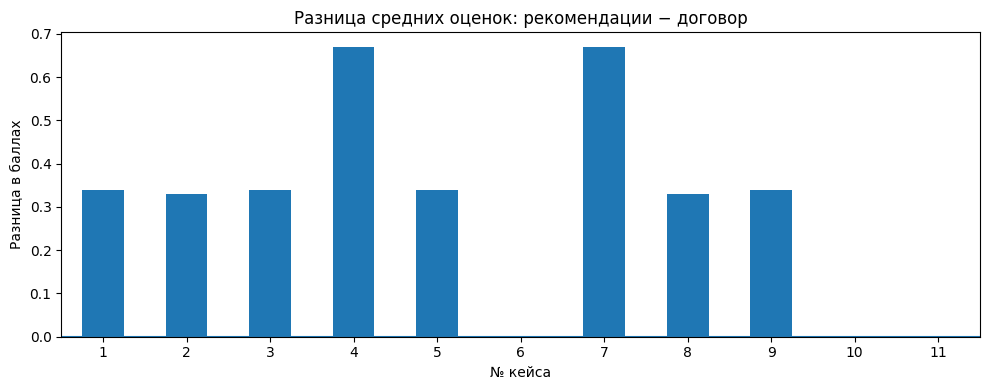

In [16]:
ax = case_analysis.plot(
    x="№ кейса",
    y="разница рекомендации − договор",
    kind="bar",
    figsize=(10, 4),
    legend=False,
)

ax.set_title("Разница средних оценок: рекомендации − договор")
ax.set_xlabel("№ кейса")
ax.set_ylabel("Разница в баллах")

plt.xticks(rotation=0)
plt.axhline(0)
plt.tight_layout()
plt.show()


## 13. График: средние оценки по экспертам

Сравнение средней строгости/лояльности экспертов по двум показателям.


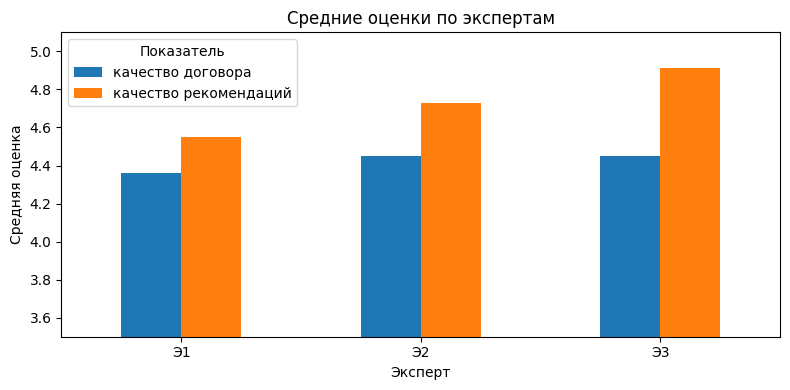

In [17]:
expert_plot = expert_analysis[
    ["качество договора", "качество рекомендаций"]
]

ax = expert_plot.plot(kind="bar", figsize=(8, 4))

ax.set_title("Средние оценки по экспертам")
ax.set_xlabel("Эксперт")
ax.set_ylabel("Средняя оценка")
ax.set_ylim(3.5, 5.1)
ax.legend(title="Показатель")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 14. График: разброс оценок по кейсам

Стандартное отклонение показывает, насколько эксперты расходились в оценках по каждому кейсу.


,№ кейса,тип договора,разброс оценок договора,разброс оценок рекомендаций
0,1,договор купли-продажи,0.58,0.58
1,2,договор продажи недвижимости,0.58,0.00
2,3,договор дарения,0.58,0.58
3,4,договор мены,0.00,0.58
4,5,договор займа,0.58,0.58
5,6,договор аренды,0.58,0.58
6,7,договор проката,0.00,0.58
7,8,договор найма жилого помещения,0.58,0.00
8,9,договор подряда,0.58,0.58
9,10,договор возмездного оказания услуг,0.58,0.58


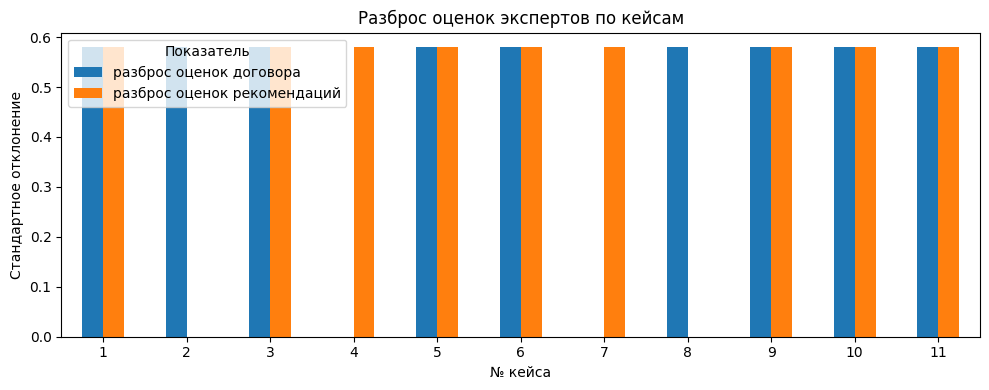

In [18]:
case_variability = df[["№ кейса", "тип договора"]].copy()
case_variability["разброс оценок договора"] = df[contract_cols].std(axis=1).round(2)
case_variability["разброс оценок рекомендаций"] = df[recommendation_cols].std(axis=1).round(2)

display(case_variability)

ax = case_variability.set_index("№ кейса")[
    ["разброс оценок договора", "разброс оценок рекомендаций"]
].plot(kind="bar", figsize=(10, 4))

ax.set_title("Разброс оценок экспертов по кейсам")
ax.set_xlabel("№ кейса")
ax.set_ylabel("Стандартное отклонение")
ax.legend(title="Показатель")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 15. Топ кейсов по средней оценке рекомендаций

In [19]:
top_recommendations = (
    case_analysis
    .sort_values(["средняя оценка рекомендаций", "средняя оценка договора"], ascending=False)
    .reset_index(drop=True)
)

display(top_recommendations)


,№ кейса,тип договора,средняя оценка договора,средняя оценка рекомендаций,разница рекомендации − договор
0,2,договор продажи недвижимости,4.67,5.00,0.33
1,8,договор найма жилого помещения,4.67,5.00,0.33
2,6,договор аренды,4.67,4.67,0.00
3,10,договор возмездного оказания услуг,4.67,4.67,0.00
4,11,агентский договор,4.67,4.67,0.00
5,1,договор купли-продажи,4.33,4.67,0.34
6,3,договор дарения,4.33,4.67,0.34
7,5,договор займа,4.33,4.67,0.34
8,9,договор подряда,4.33,4.67,0.34
9,4,договор мены,4.00,4.67,0.67


## 16. Экспорт расчетных таблиц в CSV

Эта ячейка сохраняет расчетные таблицы рядом с ноутбуком.


In [20]:
summary_counts.to_csv("expert_summary_counts_final.csv", encoding="utf-8-sig")
summary_percent.to_csv("expert_summary_percent_final.csv", encoding="utf-8-sig")
case_analysis.to_csv("expert_case_analysis_final.csv", index=False, encoding="utf-8-sig")
expert_analysis.to_csv("expert_analysis_by_expert_final.csv", encoding="utf-8-sig")
case_variability.to_csv("expert_case_variability_final.csv", index=False, encoding="utf-8-sig")

print("Файлы сохранены:")
print("- expert_summary_counts_final.csv")
print("- expert_summary_percent_final.csv")
print("- expert_case_analysis_final.csv")
print("- expert_analysis_by_expert_final.csv")
print("- expert_case_variability_final.csv")


Файлы сохранены:
- expert_summary_counts_final.csv
- expert_summary_percent_final.csv
- expert_case_analysis_final.csv
- expert_analysis_by_expert_final.csv
- expert_case_variability_final.csv


## 17. Линейный график оценок качества договора по типам договоров

По оси X указан тип договора, по оси Y — оценка качества от 0 до 5.  
Каждая линия соответствует отдельному эксперту.


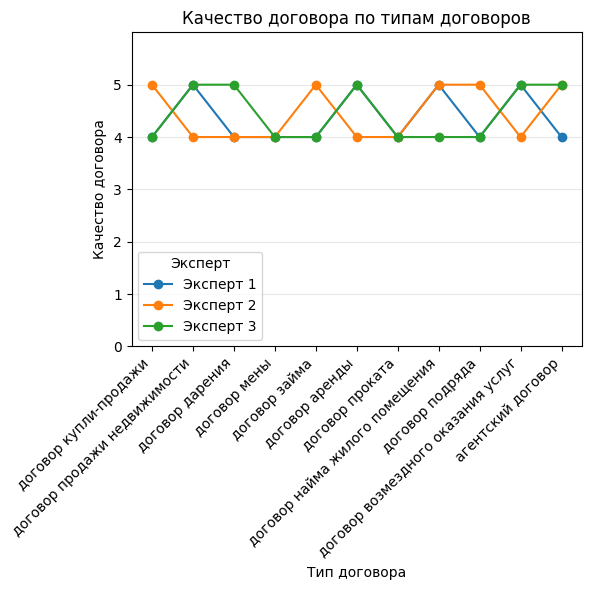

In [30]:
x_positions = range(len(df))
x_labels = df["тип договора"].tolist()

plt.figure(figsize=(6, 6))

plt.plot(
    x_positions,
    df["Э1 — договор"],
    marker="o",
    label="Эксперт 1",
    color="tab:blue",
)

plt.plot(
    x_positions,
    df["Э2 — договор"],
    marker="o",
    label="Эксперт 2",
    color="tab:orange",
)

plt.plot(
    x_positions,
    df["Э3 — договор"],
    marker="o",
    label="Эксперт 3",
    color="tab:green",
)

plt.title("Качество договора по типам договоров")
plt.xlabel("Тип договора")
plt.ylabel("Качество договора")

plt.ylim(0, 6)
plt.yticks(range(0, 6))

plt.xticks(
    ticks=list(x_positions),
    labels=x_labels,
    rotation=45,
    ha="right"
)

plt.grid(axis="y", alpha=0.3)
plt.legend(title="Эксперт")
plt.tight_layout()
plt.show()

## 18. Линейный график оценок качества рекомендаций по типам договоров

По оси X указан тип договора, по оси Y — оценка качества от 0 до 5.  
Каждая линия соответствует отдельному эксперту.


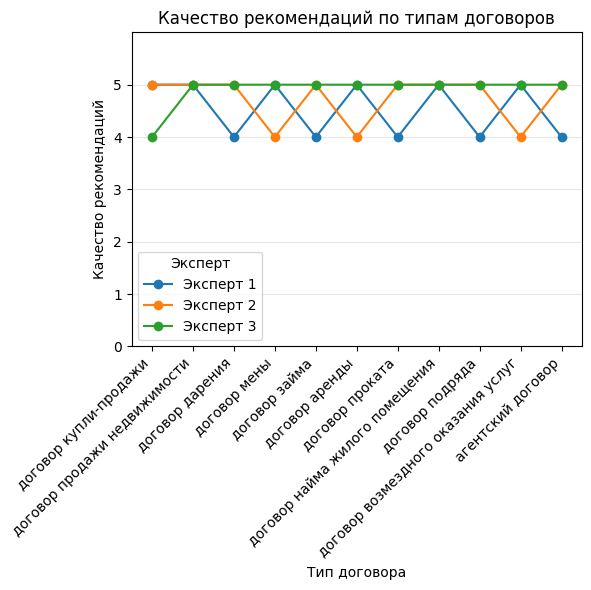

In [29]:
x_positions = range(len(df))
x_labels = df["тип договора"].tolist()

plt.figure(figsize=(6, 6))

plt.plot(
    x_positions,
    df["Э1 — отчет/рекомендации"],
    marker="o",
    label="Эксперт 1",
    color="tab:blue",
)

plt.plot(
    x_positions,
    df["Э2 — отчет/рекомендации"],
    marker="o",
    label="Эксперт 2",
    color="tab:orange",
)

plt.plot(
    x_positions,
    df["Э3 — отчет/рекомендации"],
    marker="o",
    label="Эксперт 3",
    color="tab:green",
)

plt.title("Качество рекомендаций по типам договоров")
plt.xlabel("Тип договора")
plt.ylabel("Качество рекомендаций")

plt.ylim(0, 6)
plt.yticks(range(0, 6))

plt.xticks(
    ticks=list(x_positions),
    labels=x_labels,
    rotation=45,
    ha="right"
)

plt.grid(axis="y", alpha=0.3)
plt.legend(title="Эксперт")
plt.tight_layout()
plt.show()